# Displaced Voices: Eviction Patterns in Maricopa County, AZ

This notebook analyzes 2024 eviction filings across Maricopa County census tracts by integrating U.S. Census ACS 5-Year demographic data with eviction records. Data pipeline functions are in `census_data.py`.

**Analysis flow:**
1. Descriptive statistics — income, ethnicity, rent burden, housing structure
2. K-means clustering of census tracts
3. Cluster-level visualizations
4. Collinearity analysis
5. Linear mixed-effects models (cluster as random effect)
6. Final model and interpretation


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from census_data import build_full_dataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', None)


In [3]:
fullDataset = build_full_dataset(year='2023', state='04', county='013')
print(f'Tracts: {fullDataset.shape[0]}  |  Total eviction filings: {fullDataset["filedEviction"].sum():,}')
fullDataset.head()


Tracts: 1533  |  Total eviction filings: 52,877


,GeoID,zip_code,filedEviction,medianIncome,state,county,tract,incomeLevel,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,OwnerOccupied,RenterOccupied,LiveType,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",Majority
0,04013010102,85331,1,188486,04,013,010102,Very High,0.967068,0.0,0.000000,0.000000,Single-family homes,0.763441,0.0,0.000000,0.000000,lowBurdan,0.921170,0.078830,OwnerOccupied,0.916840,0.005427,0.085874,0.0,0.012291,0.0,0.002235,0.020910,White Alone
1,04013010103,85262,1,117813,04,013,010103,Very High,0.890501,0.0,0.017150,0.049472,Single-family homes,0.815385,0.0,0.000000,0.000000,lowBurdan,0.969030,0.030970,OwnerOccupied,0.918229,0.003803,0.076881,0.0,0.000000,0.0,0.004890,0.057865,White Alone
2,04013010104,N/A,0,140587,04,013,010104,Very High,0.967761,0.0,0.000000,0.000000,Single-family homes,0.000000,0.0,0.196429,0.000000,costBurdan,0.968061,0.031939,OwnerOccupied,0.955605,0.000000,0.010220,0.0,0.007027,0.0,0.000000,0.025232,White Alone
3,04013030401,85331,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone
4,04013030401,85377,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone


## 1. Descriptive Statistics

Overview of income distribution, racial/ethnic composition, rent burden, and housing structure across all Maricopa County tracts.


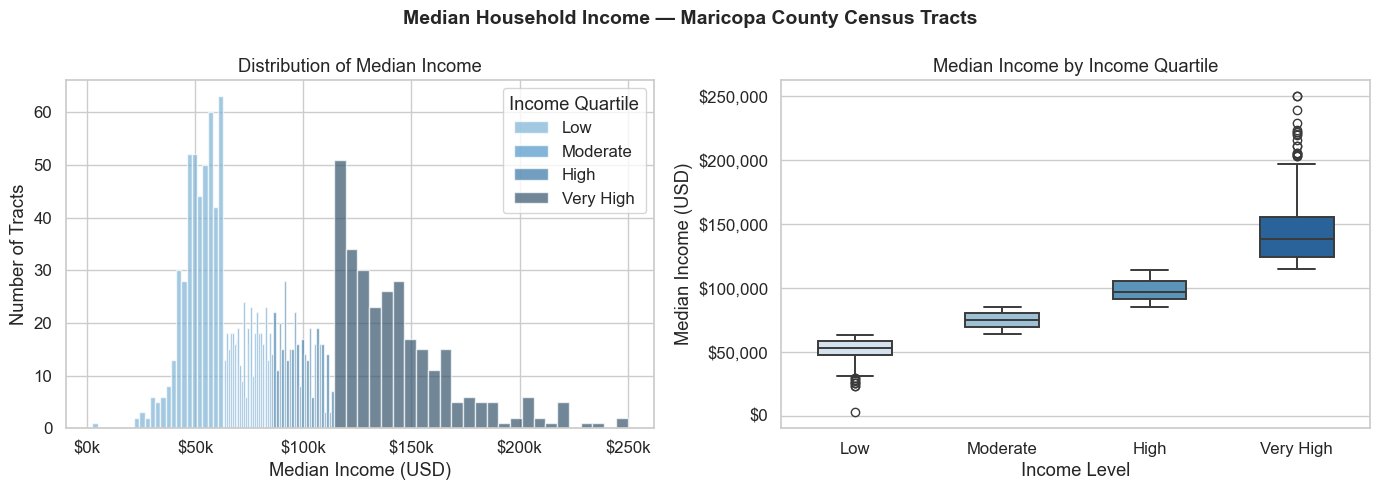

In [4]:
income_order = ['Low', 'Moderate', 'High', 'Very High']
palette_income = sns.color_palette('Blues_d', 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Median Household Income — Maricopa County Census Tracts', fontsize=14, fontweight='bold')

# Histogram with income-level color overlay
for i, level in enumerate(income_order):
    subset = fullDataset.loc[fullDataset['incomeLevel'] == level, 'medianIncome']
    axes[0].hist(subset, bins=25, alpha=0.7, label=level, color=palette_income[i])
axes[0].set_title('Distribution of Median Income')
axes[0].set_xlabel('Median Income (USD)')
axes[0].set_ylabel('Number of Tracts')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(title='Income Quartile')

# Boxplot by income level
sns.boxplot(
    data=fullDataset, x='incomeLevel', y='medianIncome',
    order=income_order,
    palette='Blues', width=0.5, linewidth=1.4,
    ax=axes[1]
)
axes[1].set_title('Median Income by Income Quartile')
axes[1].set_xlabel('Income Level')
axes[1].set_ylabel('Median Income (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


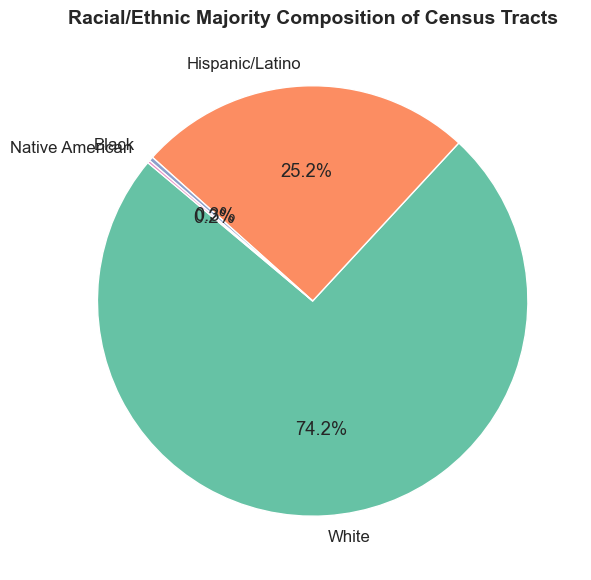

In [5]:
majority_counts = fullDataset['Majority'].value_counts()
short_labels = {
    'White Alone': 'White',
    'Hispanic or Latino': 'Hispanic/Latino',
    'Black Alone': 'Black',
    'Asian Alone': 'Asian',
    'American Indian or Alaska Native Alone': 'Native American',
    'Native Hawaiian or Pacific Islander Alone': 'Pacific Islander',
    'Some other race': 'Other',
    'Mixed race (exluding "Some other race")': 'Mixed',
}
labels = [short_labels.get(l, l) for l in majority_counts.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    majority_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(majority_counts)),
)
ax.set_title('Racial/Ethnic Majority Composition of Census Tracts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


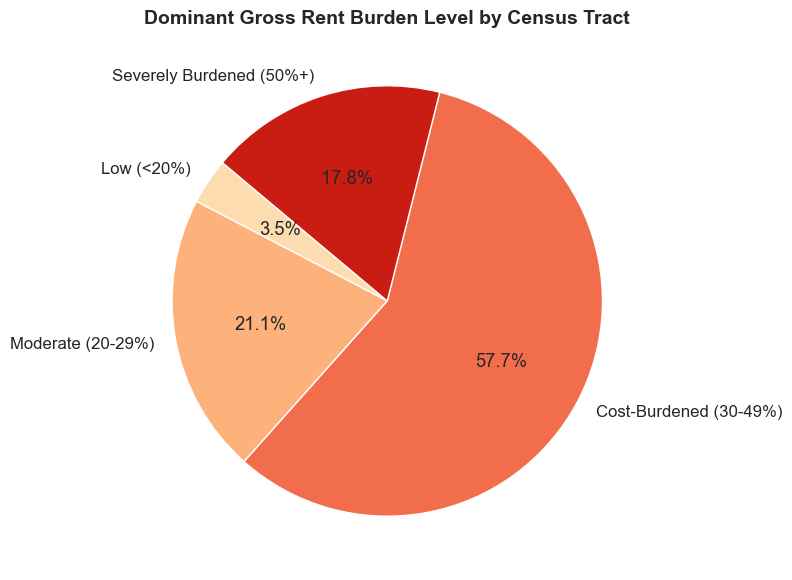

In [6]:
burden_order = ['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']
burden_labels = ['Low (<20%)', 'Moderate (20-29%)', 'Cost-Burdened (30-49%)', 'Severely Burdened (50%+)']
burden_counts = fullDataset['burden'].value_counts().reindex(burden_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    burden_counts.values,
    labels=burden_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('OrRd', 4),
)
ax.set_title('Dominant Gross Rent Burden Level by Census Tract', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


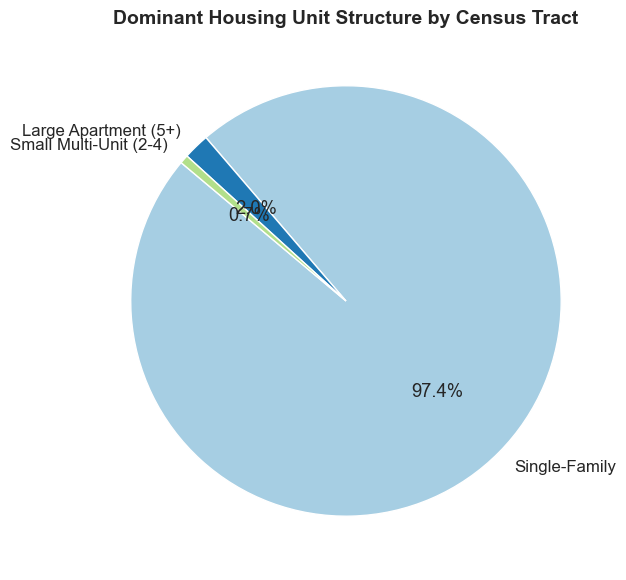

In [7]:
house_counts = fullDataset['majorHouseType'].value_counts()
house_labels = [
    l.replace('Single-family homes', 'Single-Family')
     .replace('Small multi-unit buildings (2-4 units)', 'Small Multi-Unit (2-4)')
     .replace('Larger apartment complexes (5+ units)', 'Large Apartment (5+)')
    for l in house_counts.index
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    house_counts.values,
    labels=house_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Paired', len(house_counts)),
)
ax.set_title('Dominant Housing Unit Structure by Census Tract', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. K-Means Clustering

We cluster census tracts using K-means to identify distinct socioeconomic groups. `medianIncome` is standardized via `StandardScaler`; all other features are already on [0, 1] as proportions. Categorical columns are excluded.

Optimal `k` is selected using four criteria:
- **Elbow** (WCSS): diminishing returns after the "elbow" point
- **Silhouette score**: higher = more compact, well-separated clusters
- **Calinski-Harabasz index**: higher = denser, better-separated clusters
- **Davies-Bouldin index**: lower = better separation


In [8]:
drop_cols = [
    'GeoID', 'state', 'county', 'tract', 'zip_code',
    'LiveType', 'burden', 'majorHouseType', 'incomeLevel', 'Majority', 'filedEviction',
]
df_kmeans = fullDataset.drop(columns=drop_cols).copy()

scaler = StandardScaler()
df_kmeans['medianIncome'] = scaler.fit_transform(df_kmeans[['medianIncome']])
print(f'Clustering features: {df_kmeans.shape[1]}  |  Tracts: {df_kmeans.shape[0]}')


Clustering features: 19  |  Tracts: 1533


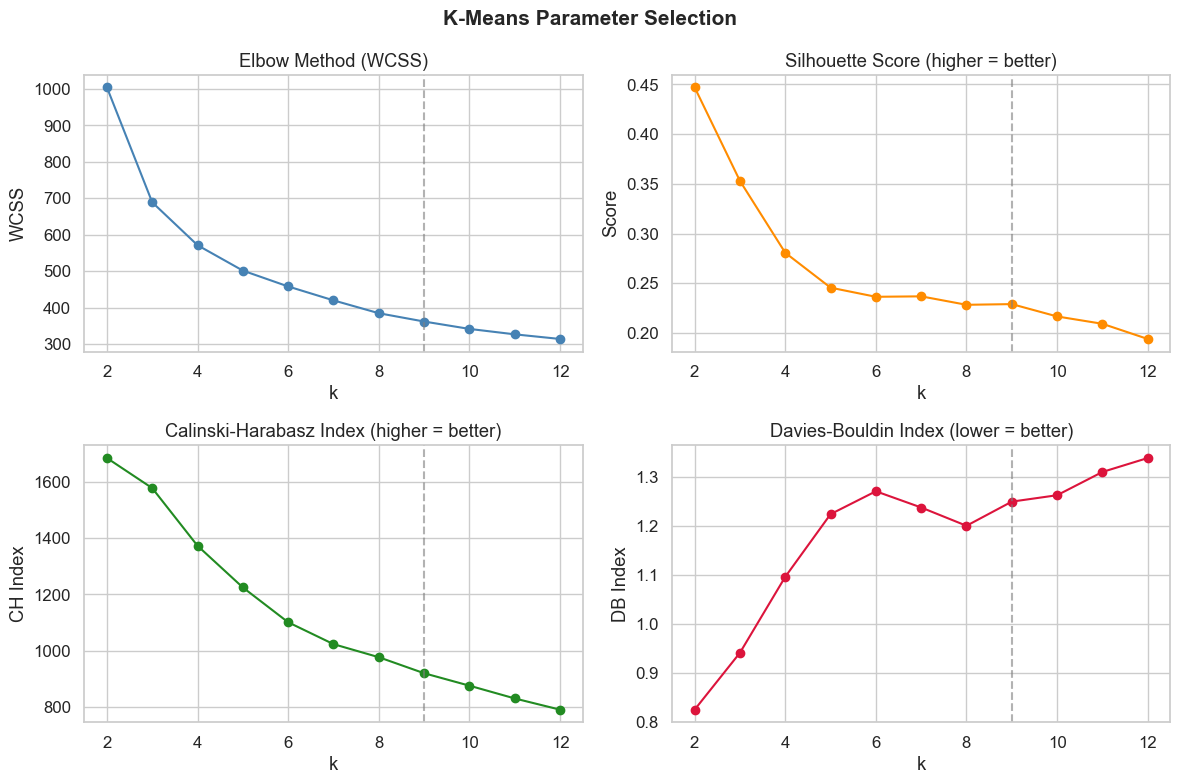

In [9]:
k_range = range(2, 13)
wcss, silhouette, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_kmeans)
    wcss.append(km.inertia_)
    silhouette.append(silhouette_score(df_kmeans, labels))
    ch_scores.append(calinski_harabasz_score(df_kmeans, labels))
    db_scores.append(davies_bouldin_score(df_kmeans, labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('K-Means Parameter Selection', fontsize=15, fontweight='bold')

axes[0, 0].plot(k_range, wcss, 'o-', color='steelblue')
axes[0, 0].set_title('Elbow Method (WCSS)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('WCSS')

axes[0, 1].plot(k_range, silhouette, 'o-', color='darkorange')
axes[0, 1].set_title('Silhouette Score (higher = better)')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Score')

axes[1, 0].plot(k_range, ch_scores, 'o-', color='forestgreen')
axes[1, 0].set_title('Calinski-Harabasz Index (higher = better)')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('CH Index')

axes[1, 1].plot(k_range, db_scores, 'o-', color='crimson')
axes[1, 1].set_title('Davies-Bouldin Index (lower = better)')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('DB Index')

for ax in axes.flat:
    ax.axvline(x=9, color='gray', linestyle='--', alpha=0.6, label='k=9')

plt.tight_layout()
plt.show()


**K selection rationale:** The elbow plot shows diminishing WCSS returns after k=2. Silhouette, CH, and DB scores continue to degrade past k=2, confirming that further splits fragment naturally cohesive groups. We select **k=2**.


In [10]:
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
fullDataset['cluster'] = km_final.fit_predict(df_kmeans) + 1

print(fullDataset['cluster'].value_counts().sort_index())


cluster
1    1047
2     486
Name: count, dtype: int64


## 3. Cluster Profiles

How do the 9 clusters differ in income, eviction volume, racial composition, and rent burden?


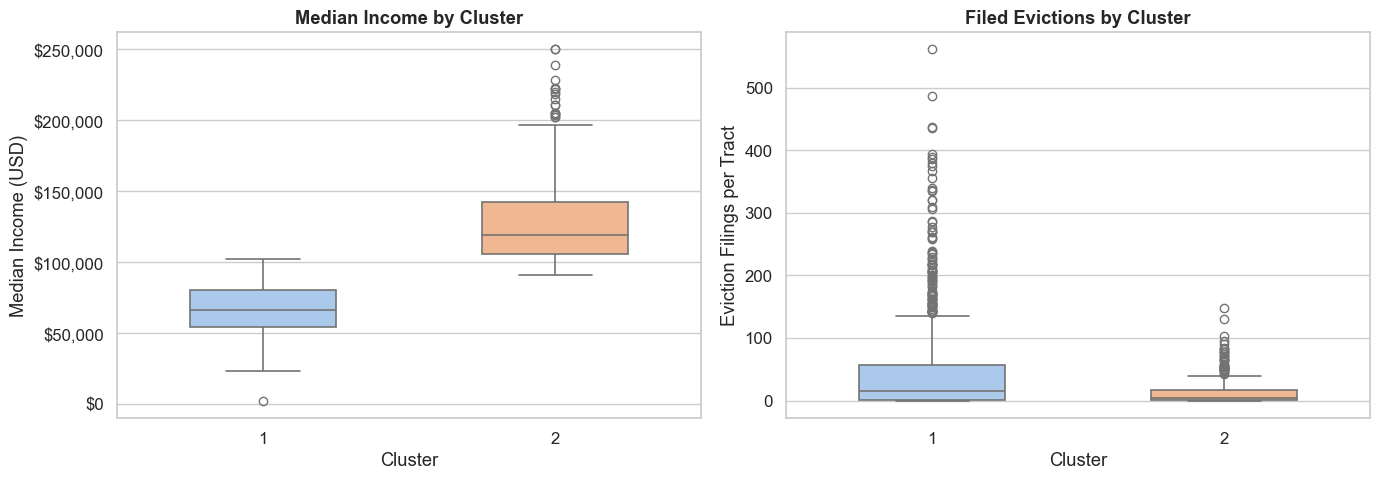

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=fullDataset, x='cluster', y='medianIncome',
    palette='pastel', width=0.5, linewidth=1.2, ax=axes[0]
)
axes[0].set_title('Median Income by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Median Income (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(
    data=fullDataset, x='cluster', y='filedEviction',
    palette='pastel', width=0.5, linewidth=1.2, ax=axes[1]
)
axes[1].set_title('Filed Evictions by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Eviction Filings per Tract')

plt.tight_layout()
plt.show()


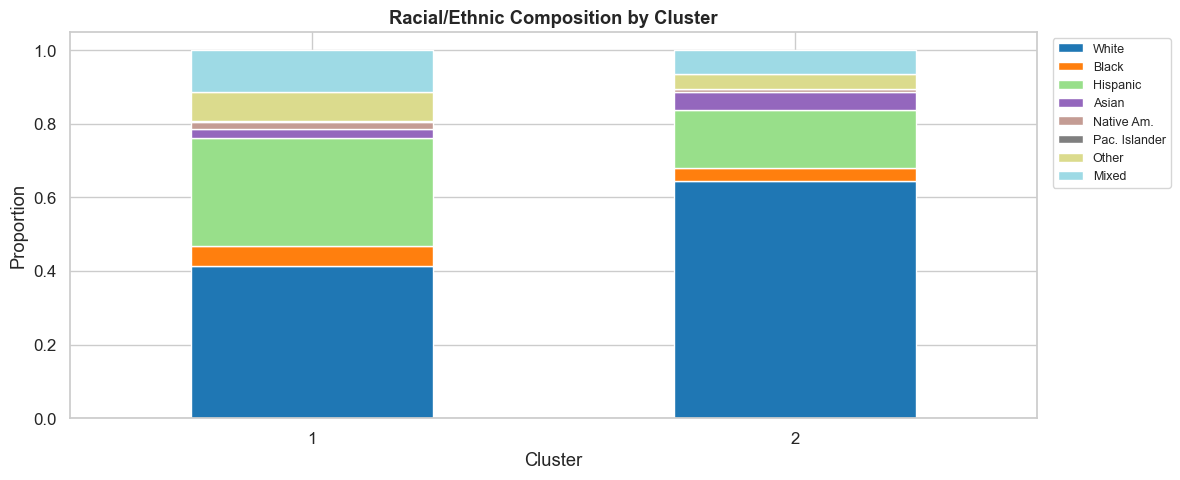

In [12]:
race_col_map = {
    'White Alone': 'White',
    'Black Alone': 'Black',
    'Hispanic or Latino': 'Hispanic',
    'Asian Alone': 'Asian',
    'American Indian or Alaska Native Alone': 'Native Am.',
    'Native Hawaiian or Pacific Islander Alone': 'Pac. Islander',
    'Some other race': 'Other',
    'Mixed race (exluding "Some other race")': 'Mixed',
}

race_avg = (
    fullDataset[['cluster'] + list(race_col_map.keys())]
    .rename(columns=race_col_map)
    .groupby('cluster').mean()
)
race_prop = race_avg.div(race_avg.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
race_prop.plot(kind='bar', stacked=True, colormap='tab20', ax=ax)
ax.set_title('Racial/Ethnic Composition by Cluster', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


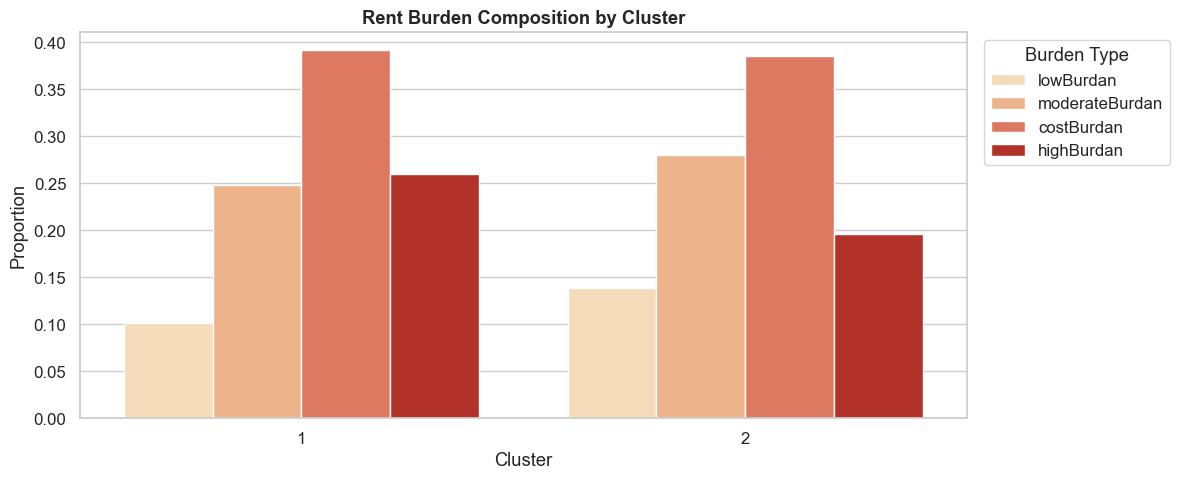

In [13]:
burden_cols = ['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']
burden_avg = fullDataset.groupby('cluster')[burden_cols].mean()
burden_prop = burden_avg.div(burden_avg.sum(axis=1), axis=0).reset_index()
burden_melt = burden_prop.melt(
    id_vars='cluster', value_vars=burden_cols,
    var_name='BurdenType', value_name='Proportion'
)
burden_melt['cluster'] = burden_melt['cluster'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=burden_melt, x='cluster', y='Proportion', hue='BurdenType',
    palette='OrRd', ax=ax
)
ax.set_title('Rent Burden Composition by Cluster', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion')
ax.legend(title='Burden Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Collinearity Analysis

Compositional variables (proportions that sum to 1 within a group) create perfect or near-perfect collinearity. We identify these before modeling:

- **Tenure:** `OwnerOccupied + RenterOccupied = 1` → keep only `RenterOccupied`
- **Burden:** `lowBurdan + moderateBurdan + costBurdan + highBurdan ≈ 1` → drop `highBurdan` as reference
- **Housing structure:** four type proportions sum to ~1 → drop `mobile_other` as reference

We examine residual correlations and VIF on the reduced set.


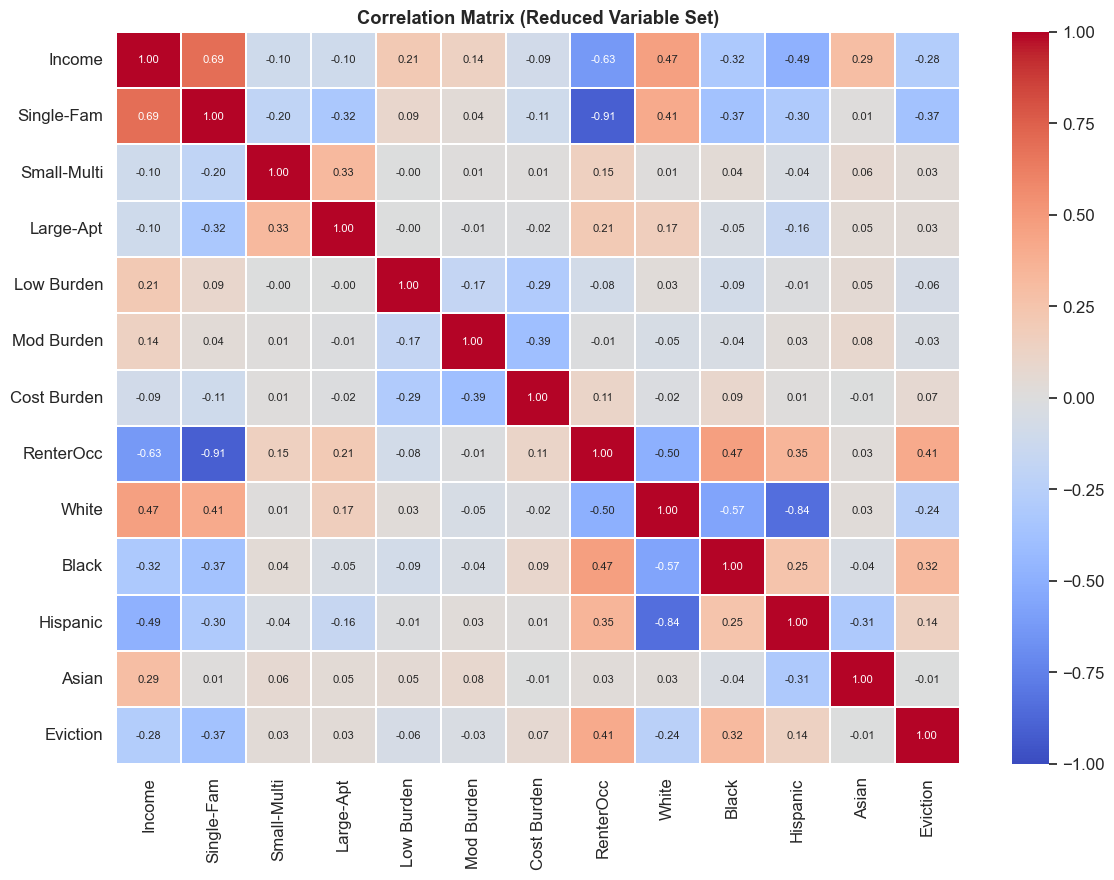

In [14]:
numeric_cols = [
    'medianIncome',
    'Single-family homes', 'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'lowBurdan', 'moderateBurdan', 'costBurdan',
    'RenterOccupied',
    'White Alone', 'Black Alone', 'Hispanic or Latino', 'Asian Alone',
    'filedEviction',
]
corr = fullDataset[numeric_cols].corr()

tick_labels = [
    'Income', 'Single-Fam', 'Small-Multi', 'Large-Apt',
    'Low Burden', 'Mod Burden', 'Cost Burden',
    'RenterOcc', 'White', 'Black', 'Hispanic', 'Asian', 'Eviction'
]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 8},
    xticklabels=tick_labels, yticklabels=tick_labels,
    ax=ax
)
ax.set_title('Correlation Matrix (Reduced Variable Set)', fontweight='bold')
plt.tight_layout()
plt.show()


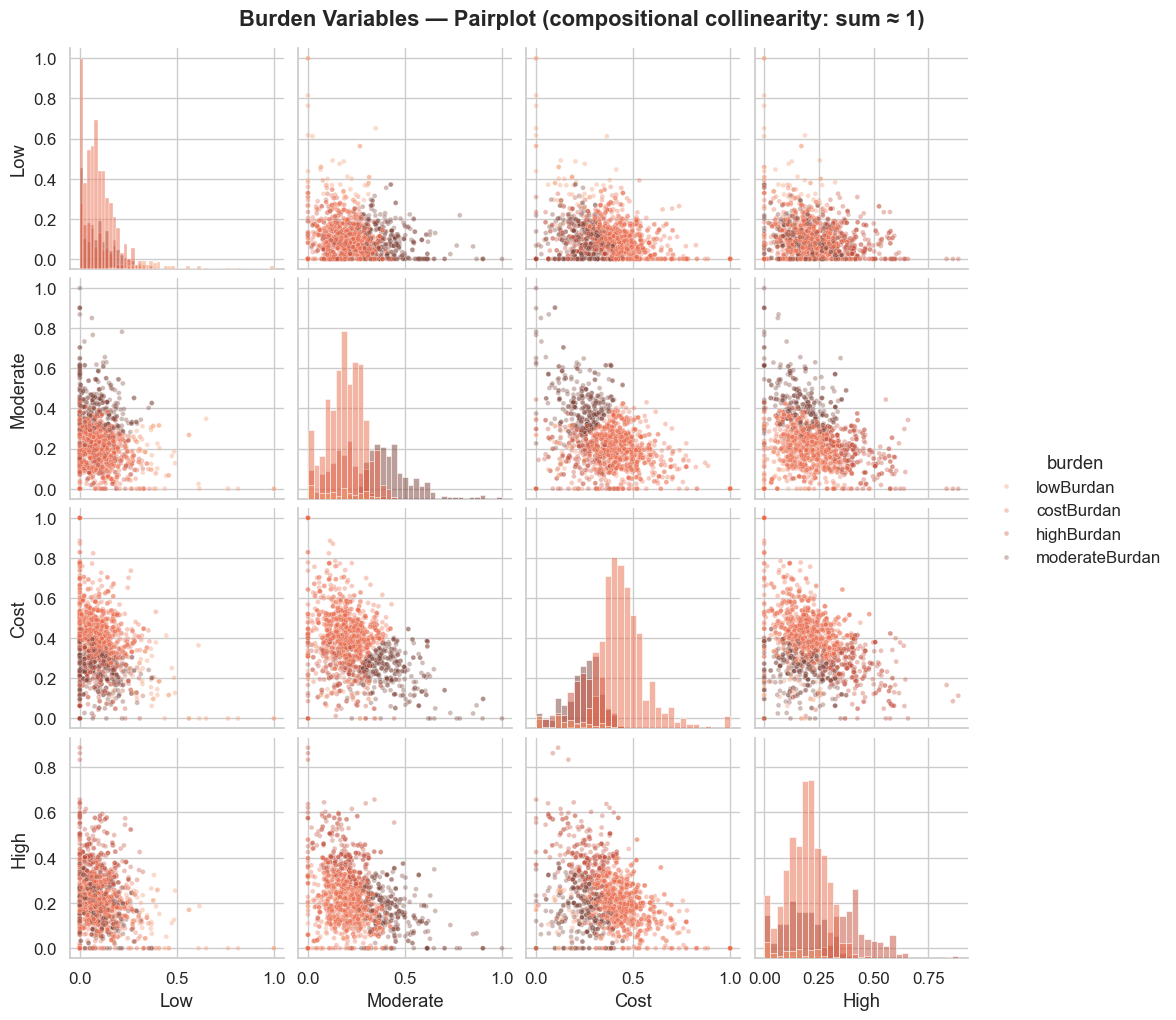

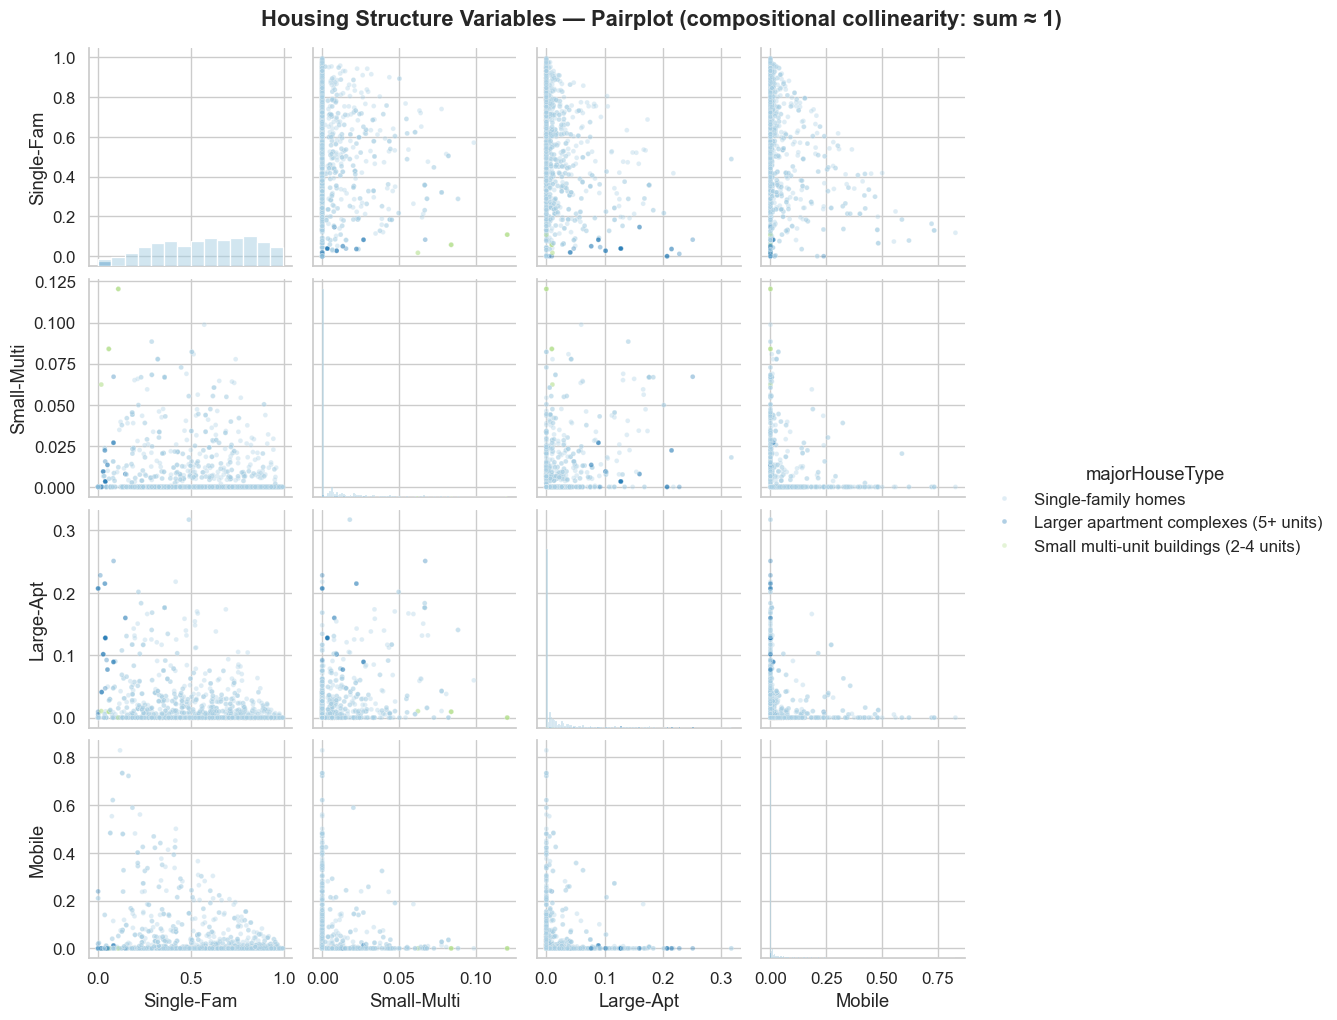

In [15]:
# ---- Pairplot: Burden compositional group ----
burden_plot = fullDataset[
    ['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan', 'burden']
].copy()
burden_plot.rename(columns={
    'lowBurdan': 'Low', 'moderateBurdan': 'Moderate',
    'costBurdan': 'Cost', 'highBurdan': 'High',
}, inplace=True)

g1 = sns.pairplot(
    burden_plot, hue='burden',
    diag_kind='hist', plot_kws={'alpha': 0.35, 's': 12},
    palette='OrRd_d',
)
g1.fig.suptitle(
    'Burden Variables — Pairplot (compositional collinearity: sum ≈ 1)',
    y=1.02, fontweight='bold',
)
plt.show()

# ---- Pairplot: Housing structure compositional group ----
house_plot = fullDataset[[
    'Single-family homes',
    'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'Mobile homes, boats, RVs, etc.',
    'majorHouseType',
]].copy()
house_plot.rename(columns={
    'Single-family homes': 'Single-Fam',
    'Small multi-unit buildings (2-4 units)': 'Small-Multi',
    'Larger apartment complexes (5+ units)': 'Large-Apt',
    'Mobile homes, boats, RVs, etc.': 'Mobile',
}, inplace=True)

g2 = sns.pairplot(
    house_plot, hue='majorHouseType',
    diag_kind='hist', plot_kws={'alpha': 0.35, 's': 12},
    palette='Paired',
)
g2.fig.suptitle(
    'Housing Structure Variables — Pairplot (compositional collinearity: sum ≈ 1)',
    y=1.02, fontweight='bold',
)
plt.show()


In [16]:
vif_cols = [
    'medianIncome',
    'Single-family homes', 'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'lowBurdan', 'moderateBurdan', 'costBurdan',
    'RenterOccupied',
    'White Alone', 'Black Alone', 'Hispanic or Latino', 'Asian Alone',
]
X_vif = fullDataset[vif_cols].dropna().copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()

vif_df = pd.DataFrame({
    'Variable': vif_cols,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(len(vif_cols))
    ],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df['Flag'] = vif_df['VIF'].apply(lambda v: 'HIGH (>10)' if v > 10 else ('MOD (5-10)' if v > 5 else 'OK (<5)'))
display(vif_df)


,Variable,VIF,Flag
0,White Alone,9.187676,MOD (5-10)
1,Single-family homes,8.116455,MOD (5-10)
2,Hispanic or Latino,7.267503,MOD (5-10)
3,RenterOccupied,7.166585,MOD (5-10)
4,medianIncome,2.934367,OK (<5)
5,Black Alone,2.472938,OK (<5)
6,Asian Alone,1.751545,OK (<5)
7,moderateBurdan,1.474492,OK (<5)
8,costBurdan,1.470089,OK (<5)
9,Larger apartment complexes (5+ units),1.403915,OK (<5)


**Collinearity findings:** Variables flagged VIF > 5 are correlated with others in the same compositional group (e.g., housing type proportions). Each LME model below focuses on one variable group at a time to avoid compounding this collinearity. The final model retains only non-redundant predictors confirmed significant in both p-value and CI checks.


## 5. Linear Mixed-Effects Models

Since `cluster` is a categorical grouping variable, we use linear mixed-effects models (`mixedlm`) with **cluster as the random effect**. The dependent variable is `log(filedEviction + 1)` to address right skew in eviction counts.

We fit one model per variable group, then select final predictors based on two criteria:
1. **p-value < 0.05**
2. **95% CI does not contain zero** (confirms the effect direction is reliable)


In [17]:
mod = fullDataset.copy()
mod['log_eviction'] = np.log(mod['filedEviction'] + 1)

mod.rename(columns={
    'Single-family homes': 'single_family',
    'Small multi-unit buildings (2-4 units)': 'small_multi',
    'Larger apartment complexes (5+ units)': 'large_apartment',
    'Mobile homes, boats, RVs, etc.': 'mobile_other',
    'White Alone': 'white',
    'Black Alone': 'black',
    'Hispanic or Latino': 'latino',
    'American Indian or Alaska Native Alone': 'native_american',
    'Asian Alone': 'asian',
}, inplace=True)


In [18]:
lme_income = smf.mixedlm(
    formula='log_eviction ~ medianIncome + C(incomeLevel)',
    data=mod,
    groups=mod['cluster'],
).fit()
print('=== Income Model ===')
print(lme_income.summary())


=== Income Model ===
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     log_eviction
No. Observations:     1533        Method:                 REML        
No. Groups:           2           Scale:                  2.2321      
Min. group size:      486         Log-Likelihood:         -2806.6269  
Max. group size:      1047        Converged:              Yes         
Mean group size:      766.5                                           
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    3.456    0.149 23.197 0.000  3.164  3.748
C(incomeLevel)[T.Moderate]   0.187    0.120  1.559 0.119 -0.048  0.421
C(incomeLevel)[T.High]       0.309    0.165  1.879 0.060 -0.013  0.632
C(incomeLevel)[T.Very High]  0.078    0.277  0.282 0.778 -0.465  0.621
me

In [ ]:
lme_live = smf.mixedlm(
    formula='log_eviction ~ RenterOccupied + C(LiveType)',
    data=mod,
    groups=mod['cluster'],
).fit()
print('=== Live Type Model (RenterOccupied; OwnerOccupied excluded — perfect collinearity) ===')
print(lme_live.summary())


In [ ]:
lme_burden = smf.mixedlm(
    formula='log_eviction ~ lowBurdan + moderateBurdan + costBurdan + C(burden)',
    data=mod,
    groups=mod['cluster'],
).fit()
print('=== Burden Model (highBurdan as reference category) ===')
print(lme_burden.summary())


In [ ]:
lme_race = smf.mixedlm(
    formula='log_eviction ~ white + black + latino + native_american + asian + C(Majority)',
    data=mod,
    groups=mod['cluster'],
).fit()
print('=== Racial Composition Model ===')
print(lme_race.summary())


In [ ]:
lme_house = smf.mixedlm(
    formula='log_eviction ~ single_family + small_multi + large_apartment + C(majorHouseType)',
    data=mod,
    groups=mod['cluster'],
).fit()
print('=== House Structure Model (mobile_other as reference) ===')
print(lme_house.summary())


## 6. Final Model Selection

We extract all fixed effects from the individual models and apply two significance filters:
- **p-value < 0.05**
- **CI does not contain zero** (lower and upper bound have the same sign)

Variables passing both filters are included in the final model.


In [ ]:
models = {
    'Income': lme_income,
    'LiveType': lme_live,
    'Burden': lme_burden,
    'Race': lme_race,
    'HouseType': lme_house,
}

records = []
for model_name, model in models.items():
    params = model.params
    pvals = model.pvalues
    conf = model.conf_int()
    for var in params.index:
        if var in ('Group Var', 'Intercept'):
            continue
        lo = conf.loc[var, 0] if var in conf.index else np.nan
        hi = conf.loc[var, 1] if var in conf.index else np.nan
        pval = pvals.get(var, np.nan)
        ci_clear = bool(lo * hi > 0) if not (np.isnan(lo) or np.isnan(hi)) else False
        records.append({
            'Model': model_name,
            'Variable': var,
            'Coef': round(params[var], 4),
            'p-value': round(pval, 4),
            'CI Lower': round(lo, 4),
            'CI Upper': round(hi, 4),
            'p<0.05': pval < 0.05,
            'CI excl. 0': ci_clear,
            'Significant': pval < 0.05 and ci_clear,
        })

sig_df = pd.DataFrame(records)
display(sig_df)

truly_sig = sig_df[sig_df['Significant']]['Variable'].tolist()
print('\nTruly significant (p<0.05 AND CI excludes zero):')
print(truly_sig)


In [ ]:
final_formula = (
    'log_eviction ~ medianIncome + RenterOccupied'
    ' + lowBurdan + moderateBurdan + costBurdan'
    ' + single_family + large_apartment + mobile_other'
    ' + white'
)

lme_final = smf.mixedlm(
    formula=final_formula,
    data=mod,
    groups=mod['cluster'],
).fit()

print('=== Final Mixed-Effects Model ===')
print(lme_final.summary())


## 7. Interpretation

### Significant predictors (p < 0.05 AND CI excludes zero)

| Variable | Direction | Interpretation |
|---|---|---|
| `medianIncome` | Negative | Higher-income tracts file fewer evictions |
| `RenterOccupied` | Positive | Greater renter share → more eviction filings |
| `lowBurdan` | Positive | Even low-burden tracts show baseline eviction pressure |
| `moderateBurdan` | Positive | Moderate rent burden (20–29%) raises eviction risk |
| `costBurdan` | Positive | Cost-burdened tracts (30–49%) show strongest burden effect |
| `single_family` | Negative | Owner-dominant single-family areas have fewer evictions |
| `large_apartment` | Negative | Dense apartment tracts have lower per-tract eviction counts |
| `mobile_other` | Negative | Mobile home tracts have fewer formal eviction filings |
| `white` | Negative | Reflects underlying income and tenure patterns, not direct causation |

### Key findings

1. **Rent burden is the strongest predictor.** Tracts where residents spend 20–49% of income on rent have substantially higher eviction rates, even after controlling for income and housing type.

2. **Income mediates but does not eliminate risk.** `medianIncome` is significant, but its effect is small — income level alone does not protect against eviction once burden is controlled for.

3. **Racial composition is not independently significant** (all race model CIs contain zero). Observed racial disparities in evictions are largely mediated by income, tenure, and burden.

4. **Cluster-level random effects capture spatial heterogeneity.** The significant `Group Var` confirms that neighborhood context — beyond individual tract characteristics — matters for eviction outcomes.

> A variable with p < 0.05 alone is insufficient. We additionally require the 95% CI to exclude zero, ensuring the estimated effect is not attributable to sampling variability.
